In [1]:
import os
import glob
import json
import numpy as np
import pandas as pd
from pathlib import Path
from skimage import measure
from PNW_cmap import PNW_cmap
import matplotlib.pyplot as plt
from vip_slap2_analysis.utils.utils import save_figure
from vip_slap2_analysis.io.session_registry import VIPSessionRegistry
from vip_slap2_analysis.voltage.summary import VoltageSummary
from vip_slap2_analysis.utils.utils import normalize

import seaborn as sns
sns.set_style('white')
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'xx-large',
         'ytick.labelsize':'xx-large'}
plt.rcParams.update(params)

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

In [2]:
%load_ext autoreload
%autoreload 2

%matplotlib notebook

In [3]:
datapath = r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-02-10_10-48-51\slap2\dynamic_data\dendriticVoltageExtraction\dendriticVoltageSummary-260422-135733.mat"
savepath = r"C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Figures\OPhys\VIP_SD\panels"

In [4]:
vs = VoltageSummary(datapath)

In [114]:
dmd1_traces = vs.get_roi_traces(dmd=1,trial=10)
dmd2_traces = vs.get_roi_traces(dmd=2,trial=10)

In [115]:
dmd = 2
meanim = vs.get_mean_image(dmd=dmd)
dmd_masks = vs.get_roi_masks(dmd=dmd)

<IPython.core.display.Javascript object>


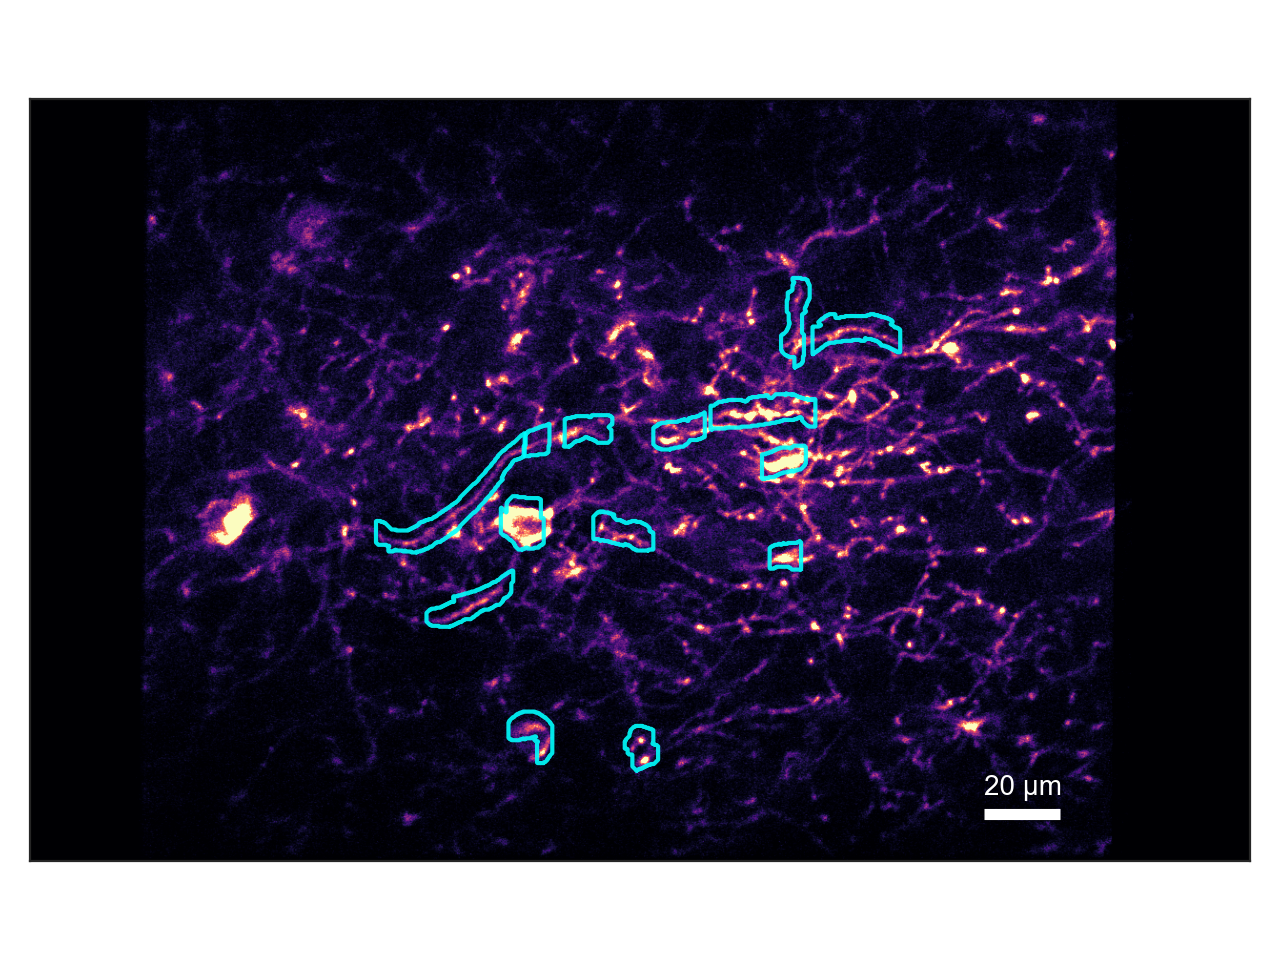

In [116]:
scale = 0.25  # um/px
fig, ax = plt.subplots()

ax.imshow(meanim, cmap="magma", vmax=200, vmin=0)

for roi_idx in range(dmd_masks.shape[-1]):
    mask = dmd_masks[:, :, roi_idx]

    # --- plot contour ---
    contours = measure.find_contours(mask.astype(float), level=0.5)
    for contour in contours:
        ax.plot(
            contour[:, 1]-10,
            contour[:, 0]-3,
            color="cyan",
            lw=1.5,
            alpha=0.9,
        )

    # --- compute centroid ---
    ys, xs = np.where(mask)
    if len(xs) == 0:
        continue

    cx = xs.mean()
    cy = ys.mean()

#     # --- add label ---
#     ax.text(
#         cx+15,
#         cy-20,
#         str(roi_idx),
#         color="cyan",
#         fontsize=12)

# scale bar
bar = 20  # um
span = bar / scale

xpos = 1000
ypos = 750

ax.plot(
    [xpos, xpos + span],
    [ypos, ypos],
    color="w",
    lw=4,
    solid_capstyle="butt",
)
ax.text(
    xpos,
    ypos - meanim.shape[0] * 0.025,
    f"{bar} μm",
    color="w",
)

ax.set_xticks([])
ax.set_yticks([])
fig.tight_layout()

filen = f'2026-04-30_VoltageImaging_DMD{dmd}_meanIM'
save_figure(fig,os.path.join(savepath,filen),formats = ['.pdf'],dpi=300)

In [118]:
im_rate = 10.8e3

<IPython.core.display.Javascript object>


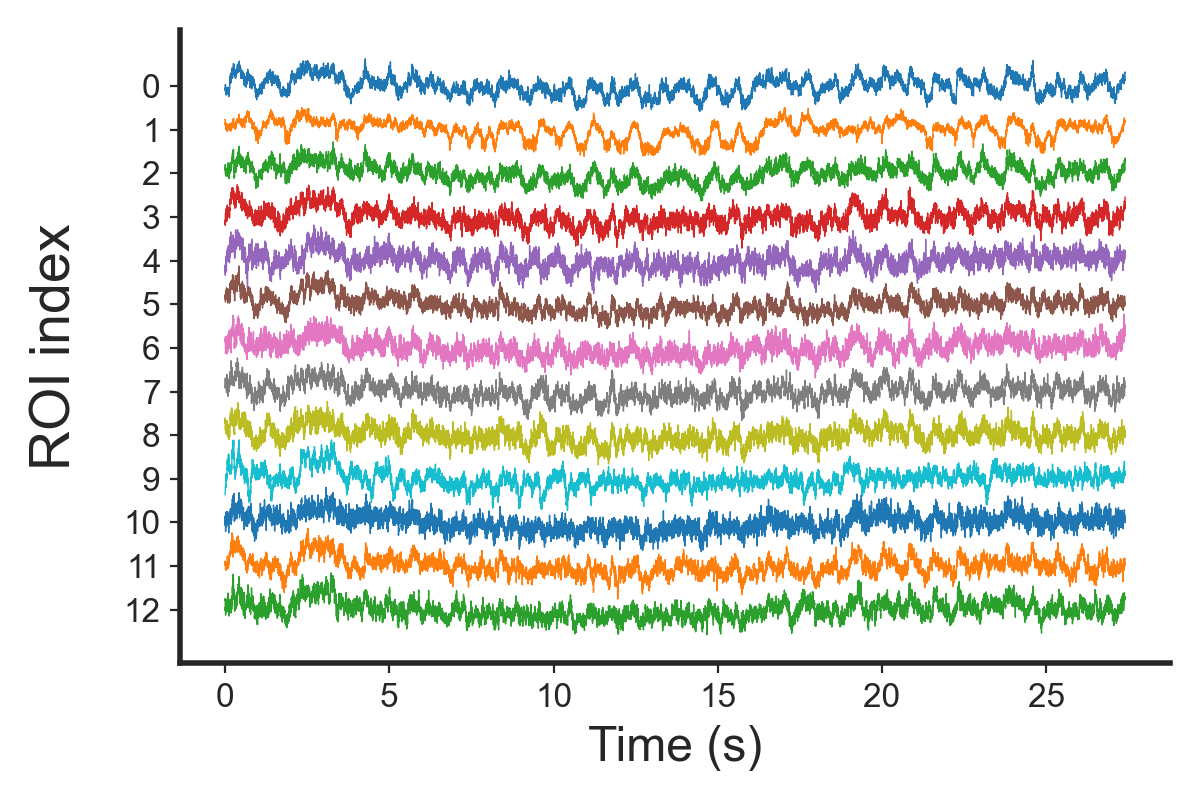

In [119]:
dmd_traces = [dmd1_traces,dmd2_traces]

plot_traces = dmd_traces[dmd-1]

stack_spacing = 5
time = np.linspace(0,plot_traces.shape[0]/im_rate,plot_traces.shape[0])
n_roi = plot_traces.shape[1]
y_offsets = -np.arange(n_roi) * stack_spacing

fig,ax=plt.subplots(figsize=(6,4))

sns.despine()

ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)

for spine in ['left','bottom']:
    ax.spines[spine].set_linewidth(2)

for roi in range(plot_traces.shape[1]):
    
    trace = plot_traces[::,roi]
    trace = (trace-np.mean(trace))/np.std(trace)
    
    ax.plot(time[::],trace[::]-stack_spacing*roi,lw=0.5)

ax.set_yticks(y_offsets)
ax.set_yticklabels([str(r-min(range(n_roi))) for r in range(n_roi)])
ax.set_ylabel("ROI index", fontsize=20,labelpad=15)    

ax.set_xlabel('Time (s)')
    
fig.tight_layout()
filen = f'2026-04-30_VoltageTrace_DMD{dmd}'
save_figure(fig,os.path.join(savepath,filen),formats = ['.pdf'],dpi=300)

<IPython.core.display.Javascript object>


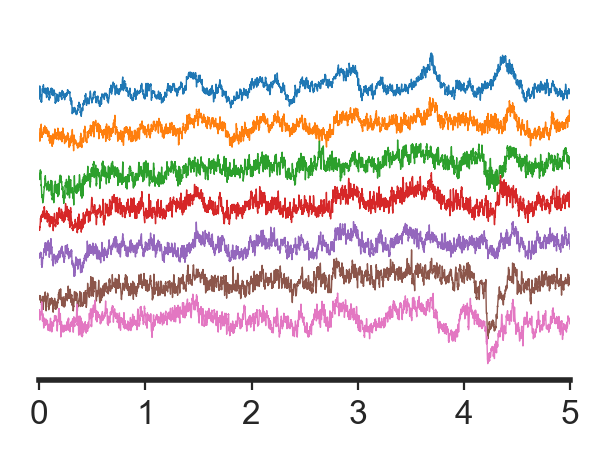

In [78]:
dmd_traces = [dmd1_traces,dmd2_traces]

plot_traces = dmd_traces[dmd-1]
skip = 2
stack_spacing = 2
time = np.linspace(0,plot_traces.shape[0]/im_rate,plot_traces.shape[0])
n_roi = plot_traces.shape[1]
y_offsets = -np.arange(n_roi)[::skip] * stack_spacing

fig,ax=plt.subplots(figsize=(3,2.3))

sns.despine(left=True)

ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)

for spine in ['left','bottom']:
    ax.spines[spine].set_linewidth(2)

for roi in range(plot_traces.shape[1])[::skip]:
    
    trace = plot_traces[::,roi]
    trace = (trace-np.mean(trace))/np.std(trace)
    
    ax.plot(time[::],trace[::]-stack_spacing*roi,lw=0.5)

ax.set_yticks([])

# ax.set_xlabel('Time (s)')
window = [0,5]
ax.set_xlim(window[0],window[1])
fig.tight_layout()
filen = f'2026-04-30_VoltageTrace_DMD{dmd}_sec{window[0]}-{window[1]}'
save_figure(fig,os.path.join(savepath,filen),formats = ['.pdf'],dpi=300)

### Correlation analysis

In [79]:
# --- basic sanity ---
assert dmd1_traces.shape[0] == dmd2_traces.shape[0], "Time dimension mismatch"

# shape: (time, rois)
T = dmd1_traces.shape[0]

# --- z-score each ROI (critical for correlation) ---
def zscore(x):
    mu = np.nanmean(x, axis=0, keepdims=True)
    sd = np.nanstd(x, axis=0, keepdims=True)
    return (x - mu) / (sd + 1e-8)

dmd1_z = zscore(dmd1_traces)
dmd2_z = zscore(dmd2_traces)

print(dmd1_z.shape, dmd2_z.shape)

(295940, 17) (295940, 13)


In [133]:
# --- within-DMD correlations ---
corr_dmd1 = np.corrcoef(dmd1_z.T)
corr_dmd2 = np.corrcoef(dmd2_z.T)

# --- across-DMD correlations ---
# shape: (n_rois_dmd1, n_rois_dmd2)
corr_cross = (dmd1_z.T @ dmd2_z) / (T - 1)

# --- R^2 versions (more interpretable magnitude) ---
r2_dmd1 = corr_dmd1**2
r2_dmd2 = corr_dmd2**2
r2_cross = corr_cross**2

<IPython.core.display.Javascript object>


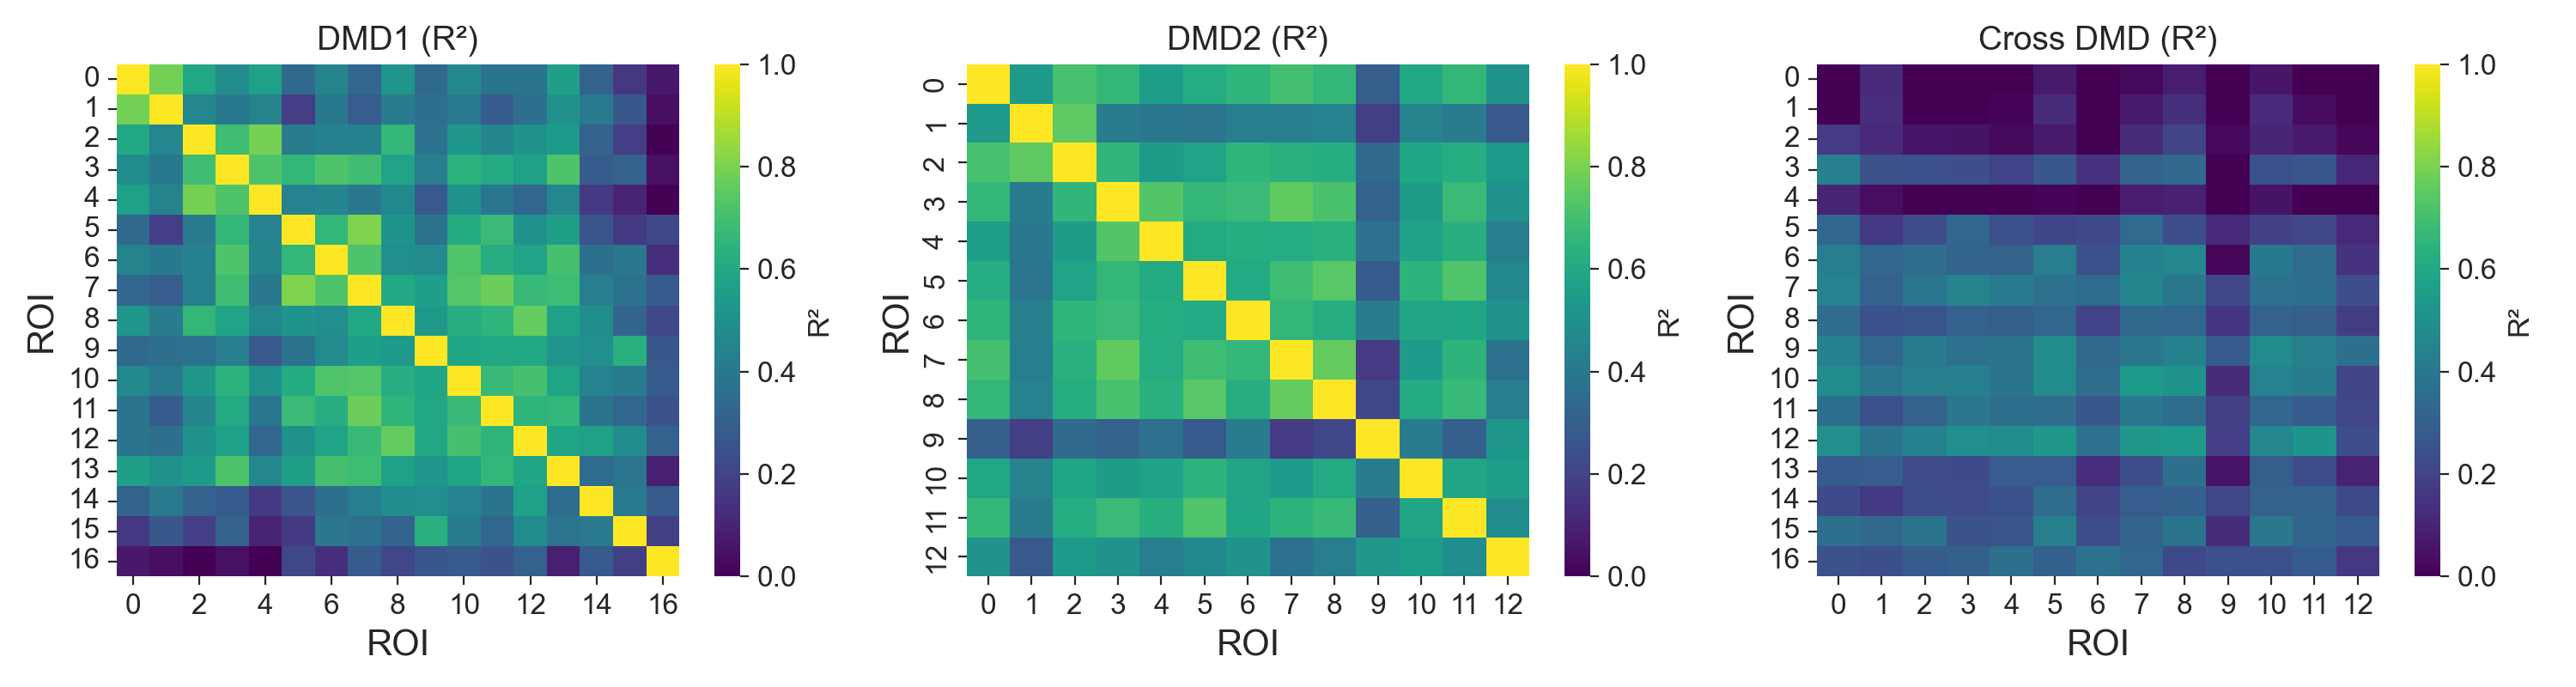

In [130]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax in axes.flatten():
    ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
    ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)  

# --- DMD1 ---
hm1 = sns.heatmap(
    r2_dmd1,
    ax=axes[0],
    cmap="viridis",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "R²"}
)
axes[0].set_title("DMD1 (R²)", fontsize=14)

# --- DMD2 ---
hm2 = sns.heatmap(
    r2_dmd2,
    ax=axes[1],
    cmap="viridis",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "R²"}
)
axes[1].set_title("DMD2 (R²)", fontsize=14)

# --- Cross ---
hm3 = sns.heatmap(
    r2_cross,
    ax=axes[2],
    cmap="viridis",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "R²"}
)
axes[2].set_title("Cross DMD (R²)", fontsize=14)

# --- formatting ---
for ax in axes:
    ax.set_xlabel("ROI", fontsize=15)
    ax.set_ylabel("ROI", fontsize=15)
    ax.tick_params(axis='both', labelsize=12)

# also set colorbar tick fontsize
for hm in [hm1, hm2, hm3]:
    cbar = hm.collections[0].colorbar
    cbar.ax.tick_params(labelsize=12)
    cbar.set_label("R²", fontsize=12)

fig.tight_layout()
filen = '2026-05-01_Voltage_Corr_heatmaps'
save_figure(fig,os.path.join(savepath,filen),formats=['.pdf'],dpi=300)

<IPython.core.display.Javascript object>


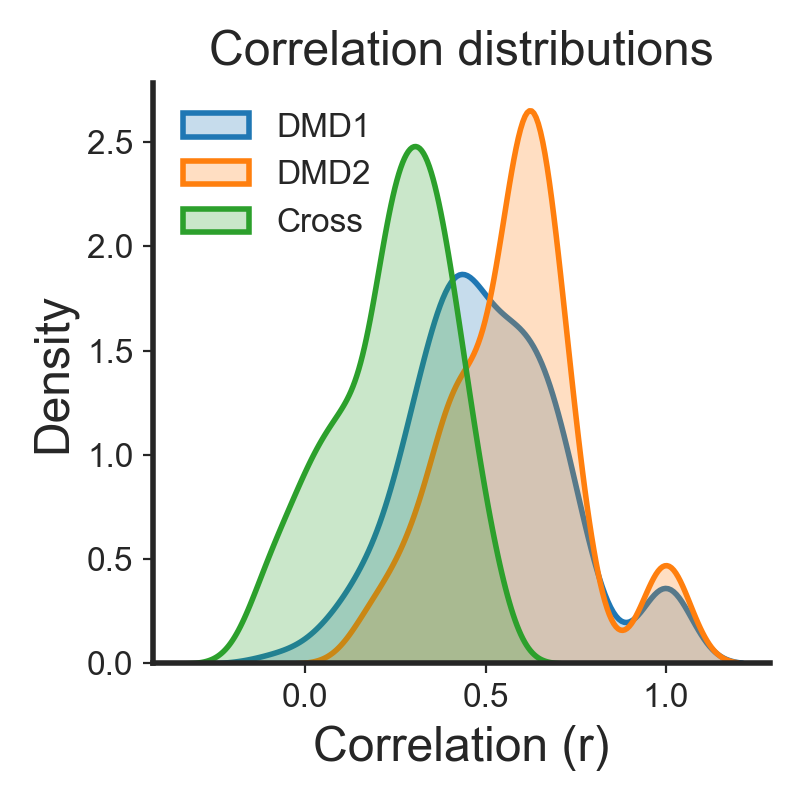

In [135]:
def upper_triangle_vals(mat):
    return mat[np.triu_indices_from(mat, k=-10)]

within1 = upper_triangle_vals(corr_dmd1)
within2 = upper_triangle_vals(corr_dmd2)
cross = corr_cross.flatten()

fig, ax = plt.subplots(figsize=(4,4))

sns.despine()

ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12) 

for spine in ['left','bottom']:
    ax.spines[spine].set_linewidth(2)

sns.kdeplot(within1, label="DMD1", ax=ax,lw=2,fill=True)
sns.kdeplot(within2, label="DMD2", ax=ax,lw=2,fill=True)
sns.kdeplot(cross, label="Cross", ax=ax,lw=2,fill=True)

ax.set_xlabel("Correlation (r)")
ax.set_ylabel("Density")
ax.legend(frameon=False,fontsize=12,loc='upper left')
ax.set_title("Correlation distributions")

plt.tight_layout()

filen = '2026-05-01_Voltage_Corr_kde'
save_figure(fig,os.path.join(savepath,filen),formats=['.pdf'],dpi=300)

In [132]:
# top correlated ROI pairs across DMDs
n_top = 10

flat_idx = np.argsort(corr_cross.flatten())[::-1][:n_top]
pairs = np.array(np.unravel_index(flat_idx, corr_cross.shape)).T

print("Top cross-DMD ROI pairs (dmd1_roi, dmd2_roi, r):")
for i, j in pairs:
    print(f"{i}, {j}, r = {corr_cross[i, j]:.3f}")

Top cross-DMD ROI pairs (dmd1_roi, dmd2_roi, r):
10, 7, r = 0.541
12, 8, r = 0.539
12, 5, r = 0.535
12, 7, r = 0.535
12, 11, r = 0.518
10, 8, r = 0.514
12, 0, r = 0.499
12, 3, r = 0.493
9, 5, r = 0.483
10, 0, r = 0.483


<IPython.core.display.Javascript object>


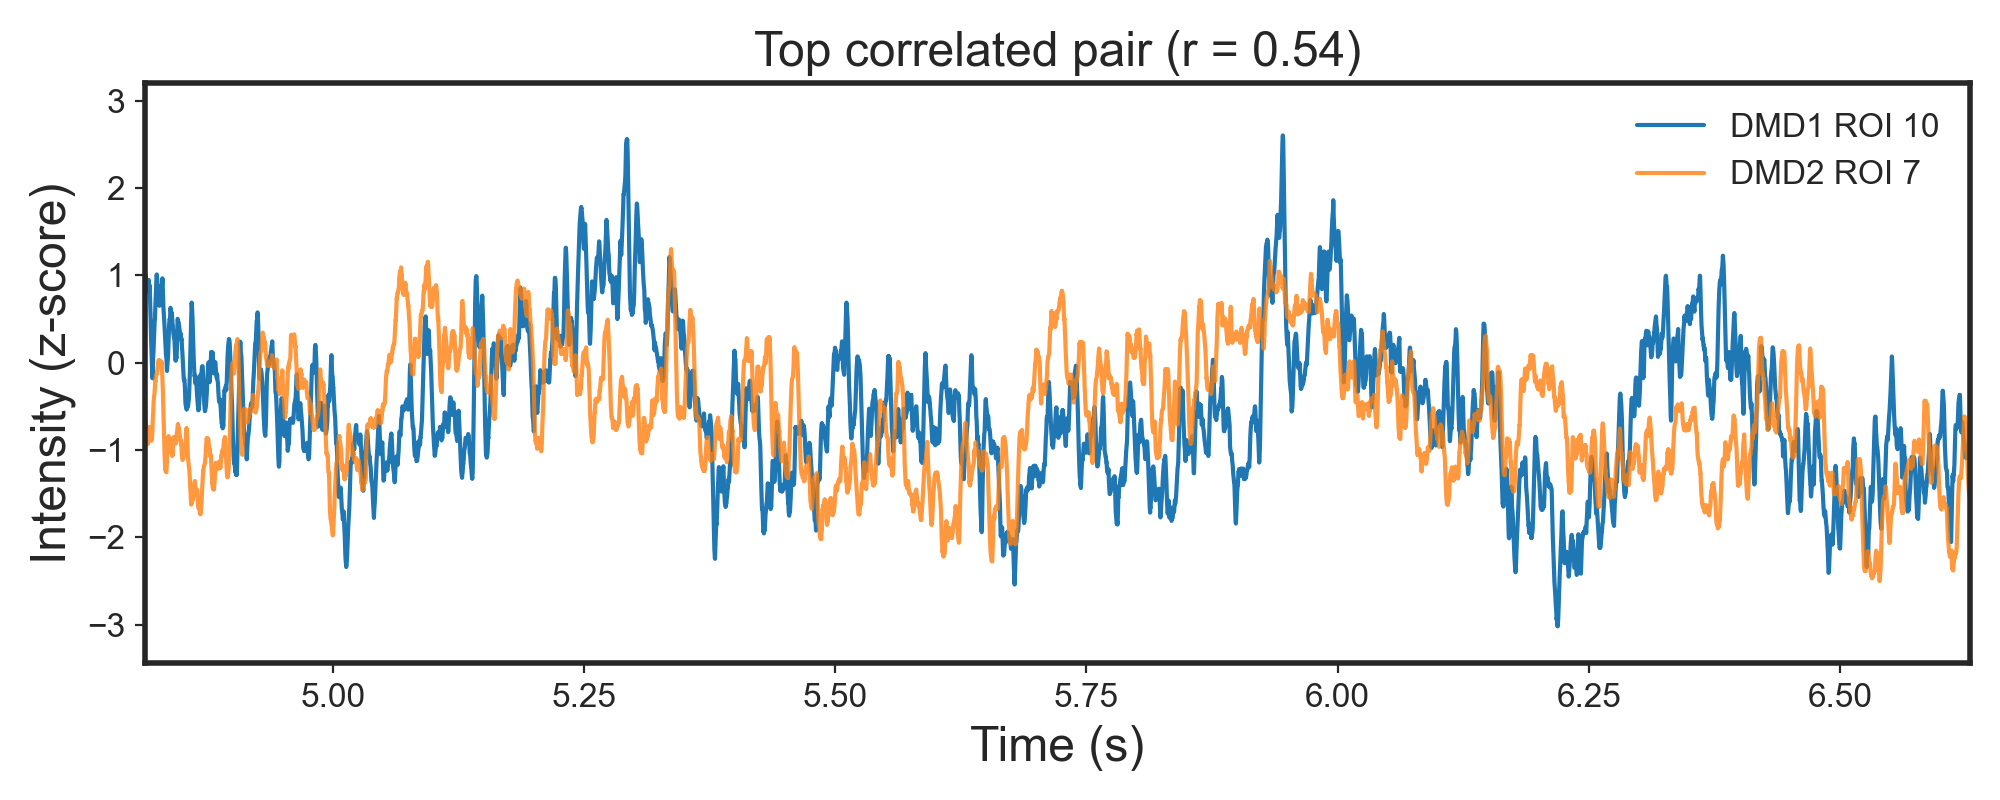

In [136]:
fig, ax = plt.subplots(figsize=(10,4))

for spine in ['left','bottom','right','top']:
    ax.spines[spine].set_linewidth(2)

ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12) 

i, j = pairs[0]  # strongest pair

ax.plot(time,dmd1_z[:, i], label=f"DMD1 ROI {i}")
ax.plot(time,dmd2_z[:, j], label=f"DMD2 ROI {j}", alpha=0.8)

ax.set_xlabel('Time (s)')
ax.set_ylabel('Intensity (z-score)')

ax.set_title(f"Top correlated pair (r = {corr_cross[i,j]:.2f})")
ax.legend(frameon=False,fontsize=12)

plt.tight_layout()
filen = '2026-05-01_Voltage_Corr_pair'
save_figure(fig,os.path.join(savepath,filen),formats=['.pdf'],dpi=300)

In [86]:
global1 = np.nanmean(dmd1_z, axis=1)
global2 = np.nanmean(dmd2_z, axis=1)

print("Global correlation:", np.corrcoef(global1, global2)[0,1])

Global correlation: 0.4549632033585343


In [87]:
def regress_out(x, g):
    beta = np.dot(x, g) / np.dot(g, g)
    return x - beta * g

dmd1_res = np.array([regress_out(dmd1_z[:,i], global1) for i in range(dmd1_z.shape[1])]).T
dmd2_res = np.array([regress_out(dmd2_z[:,i], global2) for i in range(dmd2_z.shape[1])]).T

corr_cross_res = (dmd1_res.T @ dmd2_res) / (T - 1)

<IPython.core.display.Javascript object>


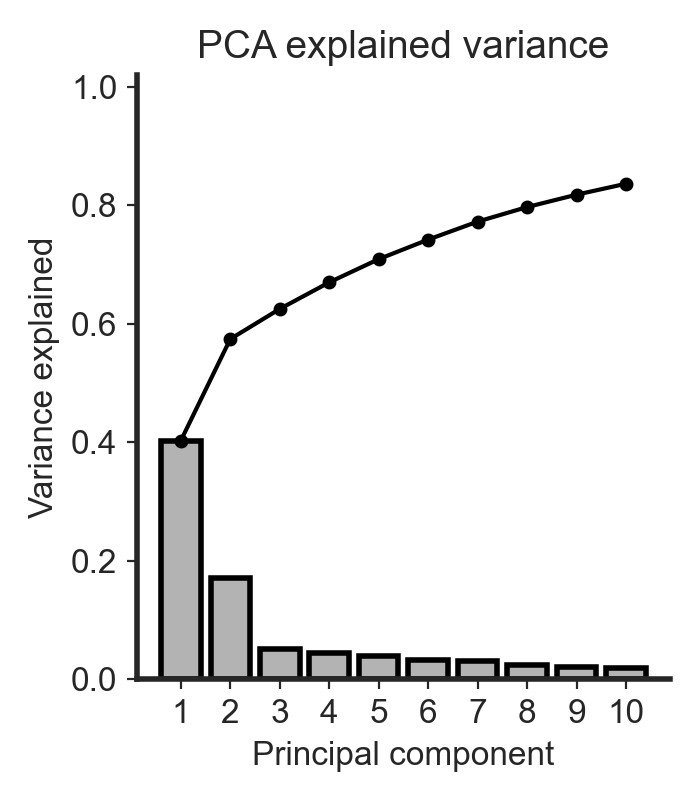

In [113]:
from sklearn.decomposition import PCA
X = np.concatenate([dmd1_z, dmd2_z], axis=1)

pca = PCA()
pca.fit(X)

explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

# number of components to display (optional cap)
n_plot = min(10, len(explained_var))

pcs = np.arange(1, n_plot + 1)

fig, ax = plt.subplots(figsize=(3.5, 4))

ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)

# --- bar: explained variance ---
ax.bar(
    pcs,
    explained_var[:n_plot],
    color='0.7',
    edgecolor='k',
    lw=2
)

# --- line: cumulative variance ---
ax.plot(
    pcs,
    cumulative_var[:n_plot],
    'o-',
    color='k',
    lw=1.5,
    ms=4
)

ax.set_xlabel('Principal component', fontsize=12)
ax.set_ylabel('Variance explained', fontsize=12)
ax.set_xticks(pcs)
ax.set_ylim(0, 1.02)
ax.set_title('PCA explained variance', fontsize=14)

sns.despine()

for spine in ['left', 'bottom']:
    ax.spines[spine].set_linewidth(2)

fig.tight_layout()

# --- save ---
filen = 'PCA_explained_variance'
save_figure(
    fig,
    os.path.join(savepath, filen),
    formats=['.pdf', '.png'],
    dpi=300
)